In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
run_name = 'norm-experiment-lr-rise'
SAVE_DIR = f'/content/drive/MyDrive/grokking/{run_name}/'   # create folder, prepend to both paths
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [6]:
import torch
ckpt = torch.load('/content/drive/MyDrive/grokking/norm-experiment-lr-rise/checkpoint.pt', map_location='cpu')
print(ckpt['optimizer']['param_groups'][0]['lr'])

0.01


In [ ]:
# config of the transformer
p=113 # the divisor in mod p. prime so it makes the modular structure clean, the model cant find shortcuts
d_model= 128 # the width of the residual stream
n_heads= 4 # 4 parrallel heads
d_head= d_model//n_heads # 32, width of each head
d_mlp = 4 * d_model # 4*d_model is convention. its the hidden width of the mlp block. the 128 vector gets expanded to 512 and then project back down to 128
n_ctx = 3 # sequence length, exactly 3 tokens which are x y =
d_vocab = p + 1 # number of distinct tokens
betas=(0.9, 0.98) # adam optimizer betas from grokking paper
#--------------experiment--------------#
lr = 1e-2 # learning rate
wd = 1.0 # weight decay. absurdly high, its the pressure that makes grokking happen fast
frac_train = 0.3 # what percentage of the data we use for training
seed = 0 # makes the run repoducible
num_epochs = 30000
eps = 1e-8

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
import random

# create each pair
def create_data(frac_train, num, seed = 0):
  pairs = [(i,j) for i in range(num) for j in range(num)]

  random.seed(seed)
  random.shuffle(pairs)
  div = int(frac_train * len(pairs))

  return pairs[:div], pairs[div:]

train, test = create_data(frac_train, p, seed)
print(len(train), len(test))

3830 8939


In [ ]:
import torch

def to_tokens(pairs, p):
  inputs = []
  labels = []
  for pair in pairs:
    inputs.append((pair[0], pair[1], p))
    labels.append((pair[0] + pair[1]) % p)

  inputs = torch.tensor(inputs)
  labels = torch.tensor(labels)

  return inputs, labels

train_inputs, train_labels = to_tokens(train, p)
test_inputs, test_labels = to_tokens(test, p)

train_inputs = train_inputs.to(device)
train_labels = train_labels.to(device)
test_inputs = test_inputs.to(device)
test_labels = test_labels.to(device)

print(len(train_inputs), len(train_labels))
print(train_inputs.shape, train_labels.shape)   # [3830, 3], [3830]
print(train_inputs.dtype)                        # torch.int64
print(train_inputs[0], train_labels[0])          # (x, y, 113) and (x+y)%113

3830 3830
torch.Size([3830, 3]) torch.Size([3830])
torch.int64
tensor([ 18,  34, 113]) tensor(52)


In [ ]:
import torch.nn as nn
import numpy as np

class Transformer(nn.Module):
  def __init__(self, d_vocab, d_model, n_ctx):
    super().__init__()
    self.W_E = nn.Parameter(torch.randn(d_vocab, d_model) / np.sqrt(d_model))
    self.W_pos = nn.Parameter(torch.randn(n_ctx, d_model) / np.sqrt(d_model))
    self.W_U = nn.Parameter(torch.randn(d_model, d_vocab) / np.sqrt(d_model))
    self.attn = Attention(d_model, n_heads, d_head, n_ctx)
    self.mlp = MLP(d_model, d_mlp)

  def forward(self, tokens):
    embed = self.W_E[tokens]
    x = embed + self.W_pos
    x = x + self.attn(x)
    x = x + self.mlp(x)
    logits = x @ self.W_U
    # print(logits.shape)
    return logits


# print(out.shape)   # torch.Size([3830, 3, 128])
# print(train_inputs.shape)
# print(model.W_E.shape)
# print(model.W_pos.shape)

In [ ]:
from einops import rearrange

class Attention(nn.Module):
  def __init__(self, d_model, n_heads, d_head, n_ctx):
    super().__init__()
    self.n_heads = n_heads
    self.d_head = d_head
    self.W_Q = nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
    self.W_K = nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
    self.W_V = nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
    self.W_O = nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
    self.register_buffer('mask', torch.tril(torch.ones(n_ctx, n_ctx)))

  def forward(self, resid):
    q = rearrange(resid @ self.W_Q, 'n s (h d) -> n h s d', h = self.n_heads)
    k = rearrange(resid @ self.W_K, 'n s (h d) -> n h s d', h = self.n_heads)
    v = rearrange(resid @ self.W_V, 'n s (h d) -> n h s d', h = self.n_heads)

    scores = (q @ k.transpose(2,3)) / np.sqrt(self.d_head)
    scores = scores.masked_fill(self.mask == 0, -1e10)
    pattern = torch.softmax(scores, dim=-1)

    z = rearrange(pattern @ v, 'n h s d -> n s (h d)', h = self.n_heads)
    o = z @ self.W_O

    return o

# attention = Attention(d_model, n_heads, d_head, n_ctx)
# outa = attention(out)
# print(outa.shape)

In [ ]:
class MLP(nn.Module):
  def __init__(self, d_model, d_mlp):
    super().__init__()
    self.W_in = nn.Parameter(torch.randn(d_model, d_mlp) / np.sqrt(d_model))
    self.W_out = nn.Parameter(torch.randn(d_mlp, d_model) / np.sqrt(d_mlp))
    self.b_in = nn.Parameter(torch.zeros(d_mlp))
    self.b_out = nn.Parameter(torch.zeros(d_model))

  def forward(self, x):
    z = x @ self.W_in + self.b_in
    h = torch.relu(z)
    return h @ self.W_out + self.b_out

# mlp = MLP(d_model, d_mlp)
# outm = mlp(outa)

In [ ]:
# start
torch.manual_seed(seed)
model = Transformer(d_vocab, d_model, n_ctx)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=betas, eps=eps)

train_losses = []
test_losses = []
weight_norms = []
train_accs, test_accs = [], []
start_epoch = 0

In [ ]:
# resume
model = Transformer(d_vocab, d_model, n_ctx).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=betas, eps=eps)
ckpt = torch.load(SAVE_DIR + 'checkpoint.pt')
model.load_state_dict(ckpt['model'])
optimizer.load_state_dict(ckpt['optimizer'])
start_epoch = ckpt['epoch'] + 1
train_losses = ckpt['train_losses']
test_losses = ckpt['test_losses']
ckpt.get('train_accs', [])
ckpt.get('test_acc', [])
# weight_norms = ckpt['norms']

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [ ]:
# resume from baseline post-grok checkpoint (lr-drop experiment)
model = Transformer(d_vocab, d_model, n_ctx).to(device)
ckpt = torch.load('/content/drive/MyDrive/grokking/baseline/ckpt_20000.pt', map_location=device)
model.load_state_dict(ckpt['model'])
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=betas, eps=eps)
start_epoch = 20000
train_losses = []
test_losses = []
weight_norms = []
train_accs, test_accs = [], []
grad_terms, decay_terms, min_sqrtv = [], [], []
print(run_name, lr, wd, SAVE_DIR)

norm-experiment-lr-rise 0.01 1.0 /content/drive/MyDrive/grokking/norm-experiment-lr-rise/


In [ ]:
# training loop
torch.save({'train': train_losses, 'test': test_losses}, SAVE_DIR + 'losses.pt')
for i in range(start_epoch, num_epochs):
  logits = model(train_inputs)
  sliced_logits = logits[:,-1,:]
  loss = torch.nn.functional.cross_entropy(sliced_logits, train_labels)

  if i % 10 == 0:
    with torch.no_grad():
      test_logits = model(test_inputs)
      test_sliced_logits = test_logits[:,-1,:]
      test_loss = torch.nn.functional.cross_entropy(test_sliced_logits, test_labels)
      train_losses.append(loss.item())
      test_losses.append(test_loss.item())

      total = 0.0
      for param in model.parameters():
        total += (param**2).sum()
      weight_norms.append(torch.sqrt(total).item())

      if len(optimizer.state) > 0:   # empty before the first step
        g2, d2, vmin = 0.0, 0.0, float('inf')
        for pa in model.parameters():
          st = optimizer.state[pa]
          t = st['step'].item() if torch.is_tensor(st['step']) else st['step']
          m_hat = st['exp_avg'] / (1 - betas[0]**t)      # bias-corrected
          v_hat = st['exp_avg_sq'] / (1 - betas[1]**t)
          upd = lr * m_hat / (v_hat.sqrt() + eps)         # gradient term
          g2 += (upd**2).sum()
          d2 += ((lr * wd * pa)**2).sum()                 # decay term
          vmin = min(vmin, v_hat.sqrt().min().item())
        grad_terms.append(torch.sqrt(g2).item())
        decay_terms.append(torch.sqrt(d2).item())
        min_sqrtv.append(vmin)
      else:
        grad_terms.append(float('nan'))
        decay_terms.append(float('nan'))
        min_sqrtv.append(float('nan'))

      if i % 500 == 0:
        print('train loss at', i, loss)
        print('test loss at', i, test_loss)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if i % 100 == 0:
    ckpt = {
      'model': model.state_dict(),
      'optimizer': optimizer.state_dict(),
      'epoch': i,
      'train_losses': train_losses,
      'test_losses': test_losses,
      'norms': weight_norms
    }
    try:
        torch.save(ckpt, SAVE_DIR + 'checkpoint.pt')
        if i % 2000 == 0:
            torch.save({'model': model.state_dict()}, SAVE_DIR + f'ckpt_{i}.pt')
    except Exception as e:
        print(f'save failed at {i}: {e}')

train loss at 20000 tensor(3.5275e-06, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 20000 tensor(2.2988e-05, device='cuda:0')
train loss at 20500 tensor(0.0002, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 20500 tensor(0.0004, device='cuda:0')
train loss at 21000 tensor(1.4310e-06, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 21000 tensor(4.8772e-06, device='cuda:0')
train loss at 21500 tensor(0.0013, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 21500 tensor(0.0023, device='cuda:0')
train loss at 22000 tensor(7.0791e-06, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 22000 tensor(2.0579e-05, device='cuda:0')
train loss at 22500 tensor(1.9724e-07, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 22500 tensor(4.3163e-07, device='cuda:0')
train loss at 23000 tensor(4.3730e-05, device='cuda:0', grad_fn=<NllLossBackward0>)
test loss at 23000 tensor(7.0146e-05, device='cuda:0')
train loss at 23500 tensor(4.7646e-07, devi

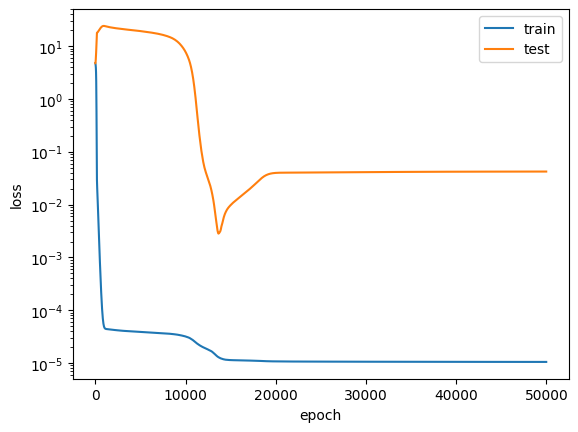

In [ ]:
import matplotlib.pyplot as plt
# test/train loss
epochs = range(0, num_epochs, 10)
# epochs = range(start_epoch, start_epoch + len(train_losses) * 10, 10) # post drop
plt.plot(epochs, train_losses, label='train')
plt.plot(epochs, test_losses, label='test')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
torch.save({'train': train_losses, 'test': test_losses}, SAVE_DIR + 'losses.pt')
plt.savefig(SAVE_DIR + f'{run_name}.png', dpi=150)
plt.show()

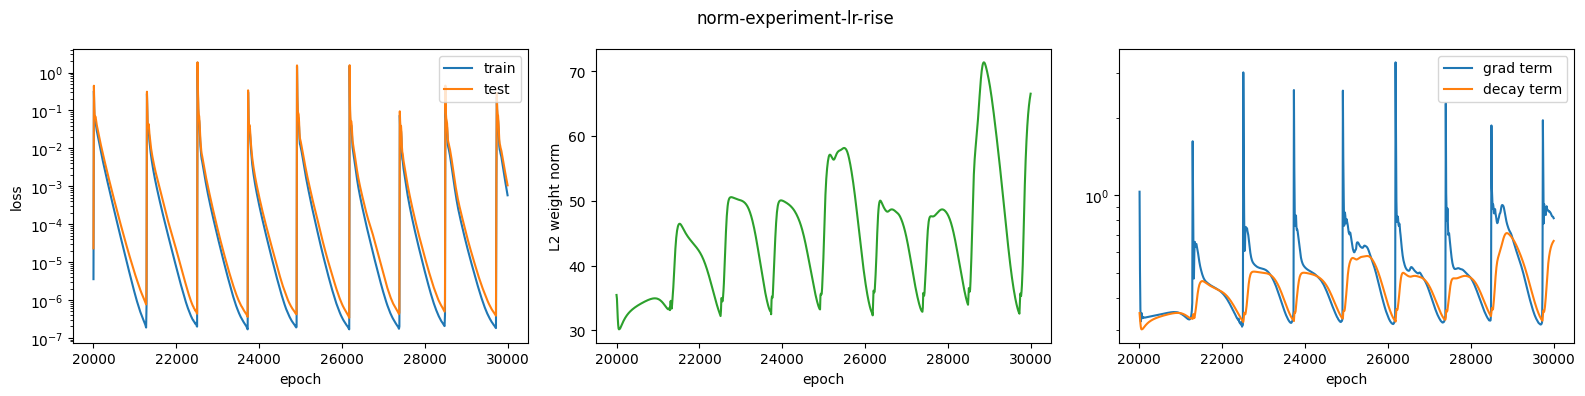

In [ ]:
import matplotlib.pyplot as plt

epochs_x = [start_epoch + j * 10 for j in range(len(train_losses))]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(epochs_x, train_losses, label='train')
ax1.plot(epochs_x, test_losses, label='test')
ax1.set_yscale('log')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.legend()

ax2.plot(epochs_x, weight_norms, c='tab:green')
ax2.set_xlabel('epoch')
ax2.set_ylabel('L2 weight norm')

ax3.plot(epochs_x, grad_terms, label='grad term')
ax3.plot(epochs_x, decay_terms, label='decay term')
ax3.set_yscale('log')
ax3.set_xlabel('epoch')
ax3.legend()

fig.suptitle(run_name)
fig.tight_layout()
torch.save({'train': train_losses, 'test': test_losses, 'norms': weight_norms,
            'grad_terms': grad_terms, 'decay_terms': decay_terms,
            'min_sqrtv': min_sqrtv}, SAVE_DIR + 'losses.pt')
fig.savefig(SAVE_DIR + f'{run_name}.png', dpi=150)
plt.show()

In [ ]:
import glob

sweep_name = 'wd0'
sweep_dir = f'/content/drive/MyDrive/grokking/{sweep_name}/'
ckpts = glob.glob(sweep_dir + 'ckpt_*.pt')

sorted_ckpts = []
for ckpt in ckpts:
  sorted_ckpts.append(((int(ckpt.split('_')[-1].split('.')[0])), ckpt))

sorted_ckpts.sort()

epochs, train_accs, test_accs, norms = [], [], [], []

with torch.no_grad():
  for epoch, path in sorted_ckpts:
    ckpt = torch.load(path, map_location=device)
    model = Transformer(d_vocab, d_model, n_ctx).to(device)
    model.load_state_dict(ckpt['model'])

    train_logits = model(train_inputs)
    train_sliced = train_logits[:,-1,:]
    train_preds = train_sliced.argmax(dim=-1)
    train_accs.append((train_preds==train_labels).float().mean().item())

    test_logits = model(test_inputs)
    test_sliced = test_logits[:,-1,:]
    test_preds = test_sliced.argmax(dim=-1)
    test_accs.append((test_preds==test_labels).float().mean().item())

    total = 0.0
    for param in model.parameters():
      total += (param**2).sum()
    norms.append(torch.sqrt(total).item())

    epochs.append(epoch)

NameError: name 'torch' is not defined

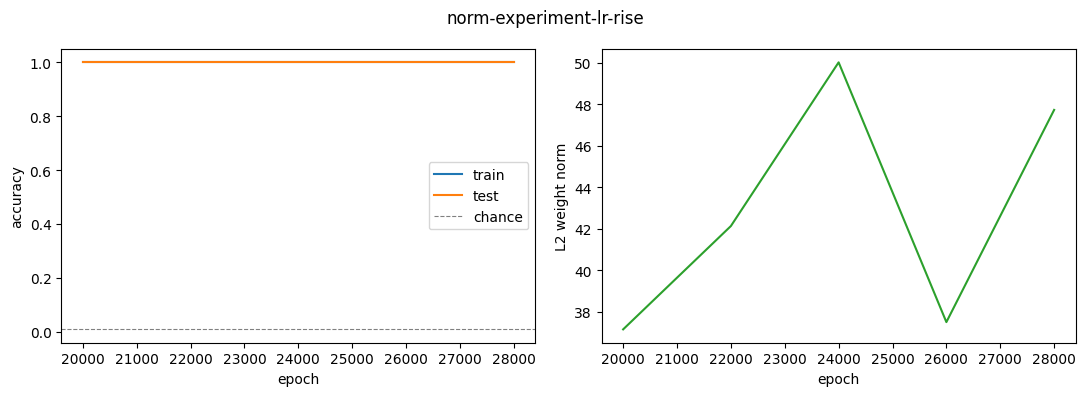

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs, train_accs, label='train')
ax1.plot(epochs, test_accs, label='test')
ax1.axhline(1/113, ls='--', c='gray', lw=0.8, label='chance')
ax1.set_xlabel('epoch')
ax1.set_ylabel('accuracy')
ax1.legend()

ax2.plot(epochs, norms, c='tab:green')
ax2.set_xlabel('epoch')
ax2.set_ylabel('L2 weight norm')

fig.suptitle(sweep_name)
fig.tight_layout()
fig.savefig(sweep_dir + f'acc_norm_{sweep_name}.png', dpi=150)
plt.show()

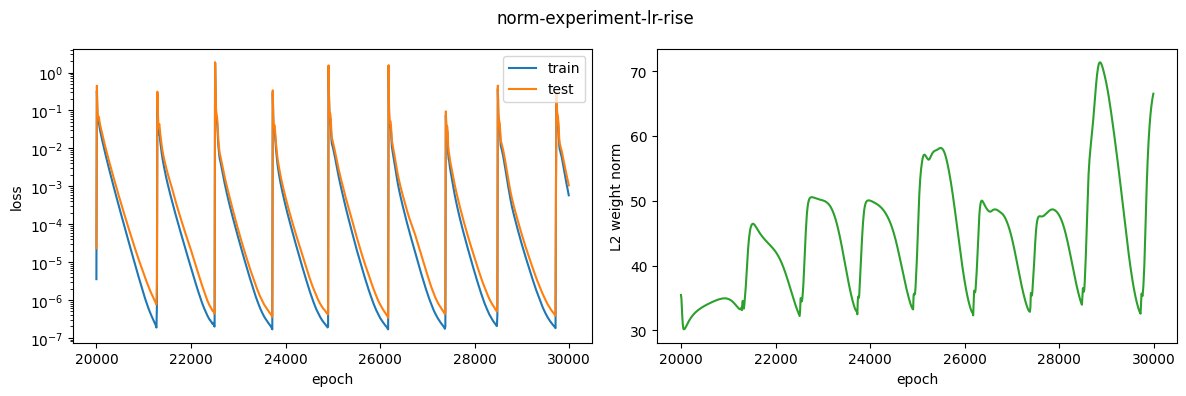

In [ ]:
import matplotlib.pyplot as plt

epochs_x = [start_epoch + j * 10 for j in range(len(train_losses))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_x, train_losses, label='train')
ax1.plot(epochs_x, test_losses, label='test')
ax1.set_yscale('log')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.legend()

ax2.plot(epochs_x, weight_norms, c='tab:green')
ax2.set_xlabel('epoch')
ax2.set_ylabel('L2 weight norm')

fig.suptitle(run_name)
fig.tight_layout()
torch.save({'train': train_losses, 'test': test_losses, 'norms': weight_norms},
           SAVE_DIR + 'losses.pt')
fig.savefig(SAVE_DIR + f'{run_name}.png', dpi=150)
plt.show()

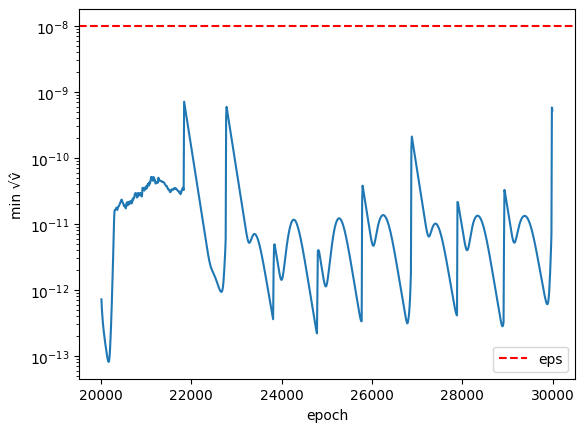

In [ ]:
d = torch.load('/content/drive/MyDrive/grokking/norm-experiment-lr-drop/losses.pt')
x = [20000 + j * 10 for j in range(len(d['min_sqrtv']))]
plt.plot(x, d['min_sqrtv'])
plt.axhline(1e-8, ls='--', c='red', label='eps')
plt.yscale('log')
plt.xlabel('epoch'); plt.ylabel('min √v̂'); plt.legend()
plt.show()